![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_3/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Recomendando Música

El objetivo de este caso-taller es construir un sistema de recomendación de Música utilizando los datos de [Last.fm](https://www.last.fm/) provistos  abiertamente por [grouplens](https://grouplens.org/about/what-is-grouplens/) para: **"avanzar la teoría y la práctica de la computación social mediante la construcción y la comprensión de sistemas *(de recomendación)* utilizados por personas reales".**

Los datos contienen información sobre artistas, usuarios, y las veces que estos escucharon sus canciones. Las bases se encuentran en los `Archivos de Laboratorio` en la carpeta `data`, allí también está disponible un archivo [README](data/readme.txt) que contiene más información sobre las bases.


## Instrucciones generales

1. Para desarrollar el *cuaderno*, primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1. Carga de datos

En la carpeta `data` se encuentran los archivos:

   - `artists.dat`  que contienen el identificador del artista (`id`), nombre (`name`), link a la página del artista en last.fm (`url`), y link a la imagen del usuario (`pictureURL`), vale aclarar que varios de estos links están rotos.
   - `user_artists.dat`  que contiene identificador del usuario (`userID`), nombre del artista que escuchó (`artistID`), y las veces que los escuchó (`weight`).

Cargue estos datos en su *cuaderno*:

   1. Para la base de artistas seleccione las columnas de identificador de artista (`id`) y nombre (`name`). Renombre estas columnas para poder hacer la unión con la base `user_artists.dat`.
   2. Para la base de usuarios y artistas, renombre las columnas de forma tal que se mantenga la consistencia para unir con la base anterior, y renombre la columna `weight` a `nro_reproducciones`.
   3. Una estas bases.
   

In [31]:
# Utilice este espacio para escribir el código.

#### Función para instalar las librerías usadas en la primera parte del Taller 1 (en caso de que no las tenga instaladas)
import sys
import subprocess

def install_load(package):
    try:
        __import__(package)
        print(f'La librería {package} ya está instalada')
    except ImportError:
        print(f'La librería {package} no se encontró. Instalando la librería {package}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f'La librería {package} ha sido instalada')    

### Lista con el nombre de las librerías usadas en el ejercicio
librerias_taller = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'scipy']

### Loop-for para las librerías
for i in librerias_taller:
    install_load(i)

#### Librerías usadas en la primera parte del Taller 1

import os                                            ##  Manejo de rutas
import numpy as np                                   ##  Computación científica en Python
import pandas as pd                                  ##  Manejo y manipulación de datos en Python
import matplotlib.pyplot as plt                      ##  Gráficos básicos en Python
import seaborn as sns                                ##  Gráficos estadísticos en Python

from sklearn.decomposition import PCA                ## Funciones para el Análisis de Componentes Principales (PCA)
from sklearn.preprocessing import StandardScaler     ## Función para estandarizar las variables numéricas
from pathlib import Path                             ##
from sklearn.metrics.pairwise import cosine_similarity ##
from scipy.sparse import csr_matrix                  ##

### Cambiamos el estilo de los gráficos de matplotlib a ggplot2 del lenguaje R
plt.style.use('ggplot')  

### Subimos un nivel en el directorio para fijar la carpeta de data
data_path = Path('..') / 'data'

### Leyendo el DataFrame con los id y nombres de los artistas
artists = pd.read_csv(data_path / 'artists.dat', 
                      sep='\t', 
                      usecols=['id', 'name'])

### DataFrame con los weights de artistas
user_artists = pd.read_csv(data_path / 'user_artists.dat', 
                           sep='\t')

### Renombramos las columnas del DataFrame artists
artists = artists.rename(columns = {
    'id': 'artistID',
    'name': 'artistName'
})

### Renombramos la columna weight del DataFrame user_artists
user_artists = user_artists.rename(columns = {
    'weight': 'nro_reproducciones'
})

### Hacemos un merge para unir los DataFrame
df_music = pd.merge(user_artists, 
                    artists, 
                    on = 'artistID', 
                    how = 'inner')

### Examinamos las cinco primeras filas del DataFrame
display(df_music.head())


La librería numpy ya está instalada
La librería pandas ya está instalada
La librería matplotlib ya está instalada
La librería seaborn ya está instalada
La librería sklearn ya está instalada
La librería scipy ya está instalada


,userID,artistID,nro_reproducciones,artistName
0,2,51,13883,Duran Duran
1,2,52,11690,Morcheeba
2,2,53,11351,Air
3,2,54,10300,Hooverphonic
4,2,55,8983,Kylie Minogue


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**Creación de la función install_load():** construímos la función install_load() para verificar si las librerías necesarias para desarrollar el ejercicio están instaladas en el computador local, si no ocurre lo anterior las librerías son instaladas mediante el paquete -pip. Posteriormente, importamos las librerías que vamos a utilizar en el taller.

**Descripción del código:** con la función *plt.style.use* cambiamos el estilo de gráficos de matplotlib, al de ggplot2 del lenguaje R. Con la librería *pathlib*, importamos la función *Path*, fijamos el directorio de trabajo en la carpeta de *data* de nuestro repositorio de GitHub, dentro de esta carpeta están almacenados los archivos de *user_artists* y *artists*, con extensión .dta, que son el insumo de nuestro taller. Estos DataFrame los cargamos mediante la función *pd.read_csv()*, de la librería Pandas, y los almacenamos en los objetos con su respectivo nombre.

**Cambios en los dataframe y merge:** en primer lugar renombramos las columnas *id* por *artistID* y *artistName* por *name*, además de cambiar el título de *weight* por *nro_reproducciones*. El siguiente paso consiste en hacer un merge entre ambos DataFrames, uniéndolos mediante la columna *artistID*, y guardando el resultado en el objeto *df_music*.

### 2. Análisis preliminar.

En esta sección exploraremos la base. Para ello responda las siguientes preguntas.

#### 2.1 ¿Cuantos usuarios y artistas hay en la base?


In [32]:
### 1. Buscamos los artistas y usuarios únicos en el DataFrame
num_usuarios = df_music['userID'].nunique()
num_artistas = df_music['artistID'].nunique()

print(f'El número total de usuarios es {num_usuarios}')
print(f'El número total de artistas es {num_artistas}')

El número total de usuarios es 1892
El número total de artistas es 17632


**Número de usuarios y artistas:** para calcular los usuarios y artistas únicos, es necesario separar la columna del DataFrame y aplicarle la función *nunique()* que nos permite calcular los valores únicos de cada columna.


#### 2.2 ¿Cuáles es la distribución de probabilidad del consumo por artista? (haga el calculo sin ponderar y ponderando por el numero de reproducciones) ¿Qué podemos inferir a partir de la comparación de ambas?

In [33]:
# Utilice este espacio para escribir el código.

### 1. Distribuciones de probabilidad 

## a. Distribución del consumo sin ponderar
dist_nw = df_music.groupby('artistName').size() / len(df_music)


## b. Distribución del consumo ponderado

# Sumamos la totalidad de filas de la columna nro_reproducciones y guardamos el resultado en el objeto total_reproducciones
total_reproducciones = df_music['nro_reproducciones'].sum()

# Realizamos una agrupación por artistName y sumamos su nro_reproducciones, posteriormente lo dividimos por el objeto total_reproducciones
prob_ponderada = df_music.groupby('artistName')['nro_reproducciones'].sum() / total_reproducciones

# Construímos un nuevo DataFrame que contenga las probabilidades ponderadas y sin ponderar, ordenamos por la prob ponderada y nos quedamos con el Top 10
df_probs = pd.DataFrame({'Prob_sin_Ponderar': dist_nw, 
                         'Prob_Ponderada': prob_ponderada,}).sort_values(by='Prob_Ponderada', 
                                                                         ascending=False).head(10) 

df_probs

,Prob_sin_Ponderar,Prob_Ponderada
artistName,,
Britney Spears,0.005623,0.034591
Depeche Mode,0.003038,0.018809
Lady Gaga,0.006582,0.018666
Christina Aguilera,0.004384,0.015298
Paramore,0.004298,0.013926
Madonna,0.004621,0.013315
Rihanna,0.005214,0.013087
Shakira,0.003436,0.009952
The Beatles,0.005171,0.009570


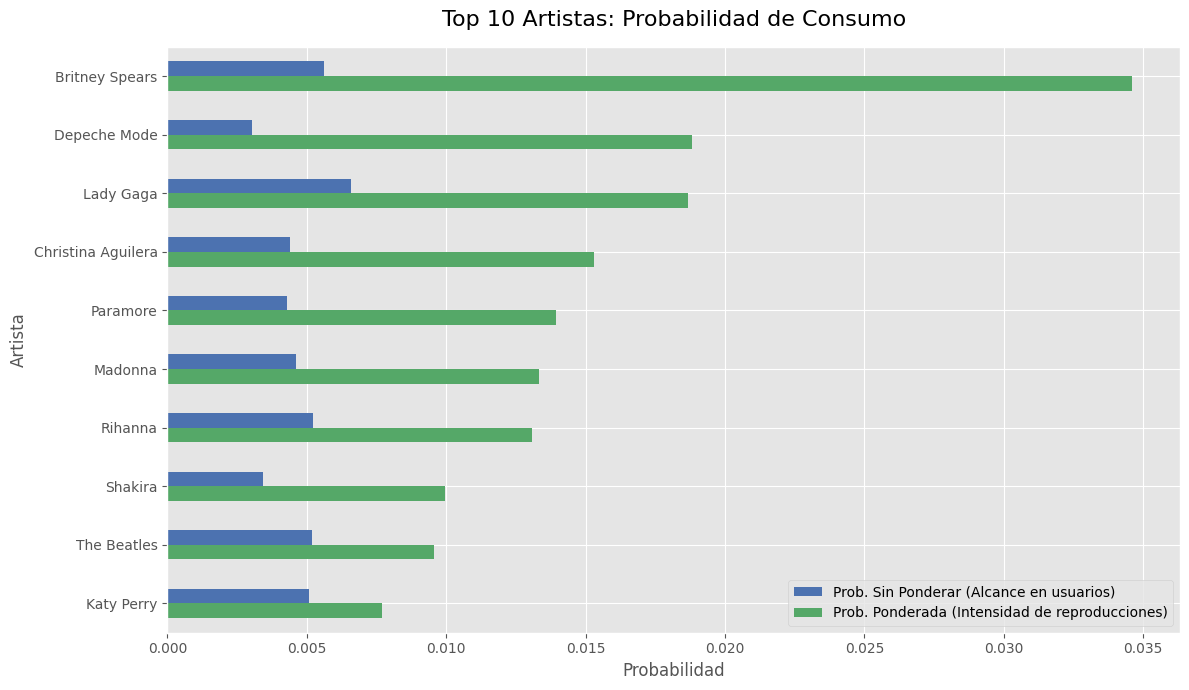

In [34]:
#### 1. Construimos un diagrama de barras (horizontal) para 

### a. Definimos el color de las barras
ax = df_probs.plot(kind='barh', 
                   figsize=(12, 7), 
                   color=['#4C72B0', 
                          '#55A868'])

### b. Personalizar títulos y etiquetas
plt.title('Top 10 Artistas: Probabilidad de Consumo', 
          fontsize = 16, 
          pad = 15)
# Título del eje X
plt.xlabel('Probabilidad', 
           fontsize=12)
# Título del eje Y
plt.ylabel('Artista', 
           fontsize=12)

# Título de la gráfica
plt.legend(['Prob. Sin Ponderar (Alcance en usuarios)', 
            'Prob. Ponderada (Intensidad de reproducciones)'], 
           loc='lower right')

# Invertir el eje Y
plt.gca().invert_yaxis()

# Ajustando los márgenes
plt.tight_layout()
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**Distribución sin ponderar:** la probabilidad sin ponderación la calculamos mediante la agrupación de la columna con el nombre de los artistas(*artistName*) por su tamaño y se divide cada agrupación por el número total de filas de DataFrame.

**Distribución ponderada:** agrupamos las categorías de la columna *artistName* y sumamos sus respectivos valores de la columna *nro_reproducciones*, posteriormente dividimos cada uno de estos resultados entre la suma total de los valores de la columna *nro_reproducciones*.

**Top 10:** en el DataFrame *df_probs* pegamos las columnas de *artistName* (nombre de los artistas), Probabilidades sin ponderar (*Prob_sin_Ponderar*) y probabilidades ponderadas (*Prob_Ponderada*).

**Construcción de la gráfica:** con la librería *Matplotlib* construimos un barplot invertido que tiene en las barras azules la probailidad sin ponderar y en las verdes la probabilidad ponderada. La probabilidad sin poderar nos indica la popularidad del artista y la ponderada indica la fidelidad de las escuchas.

**Análisis del Barplot:** la probabilidad sin ponderar (barra azul) nos indica la existencia de nichos(principalmente para Lady Gaga, Britney Spears y The Beatles) en donde los oyentes son muy fieles y reproducen varias veces las canciones de sus artistas favoritas. La probabilidad ponderada (barra verde) muestra la popularidad del artista, que da el orden de las categorías de mayor a menor, que en este caso corresponde a Britney Spears como la artista más polar d ela muestra estudiada.

#### 2.3 Para el usuario 8 (`userID==8`) ¿cuál es la distribución de reproducción de artistas basado en el número de reproducciones relativas?. Presente sus resultados usando tablas y/o gráficas. ¿Encuentra algún patrón en los artistas que escucha y las veces que reproduce? ¿Podemos decir algo de sus preferencias?


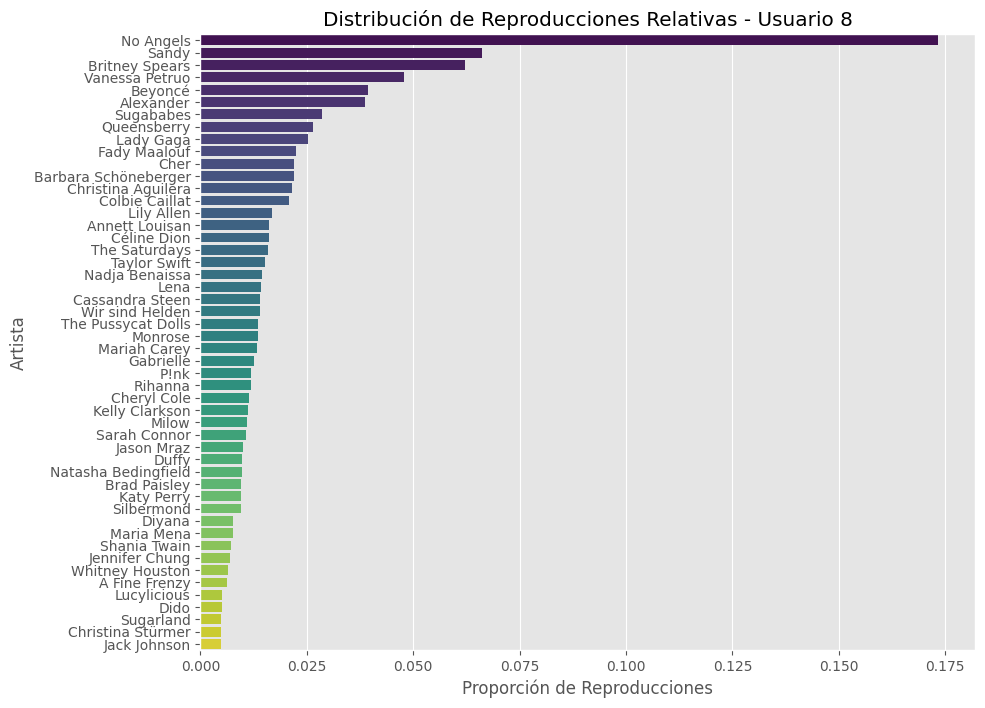

In [35]:
# Utilice este espacio para escribir el código.

### 1. Estudiando al usuario número ocho

### a. Filtramos las categorías del usuario número ocho del DataFrame df_music
user_8 = df_music[df_music['userID'] == 8]

### b. Calculamos las reproducciones relativas del usuario 8

## Sumamos los valores de la columna nro_reproducciones y guardamos el resultado en el objeto user_8_sum 
user_8_sum = user_8['nro_reproducciones'].sum()

## Añadimos la columna rep_relativa que representa las reproducciones relativas
user_8['rep_relativa']= user_8['nro_reproducciones'] / user_8_sum

### c. Reordenamos el DataFrame user_8 de mayor a menor
user_8_ord = user_8.sort_values(by = 'rep_relativa', 
                                ascending = False)

### d. 
plt.figure(figsize = (10, 8))
sns.barplot(x = 'rep_relativa', 
            y = 'artistName', 
            data = user_8_ord, 
            hue = 'artistName', 
            palette = 'viridis', 
            legend = False)
plt.title('Distribución de Reproducciones Relativas - Usuario 8')
plt.xlabel('Proporción de Reproducciones')
plt.ylabel('Artista')
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**Descripción del código:** iniciamos con un filtro de las columnas que corresponden a ID de usuario que es igual a ocho, obtenemos la suma total de todas las reproducciones (*nro_reproducciones*) y finalmente creamos las probabilidades relativas mediante la división entre *nro_reproducciones* y su respectiva suma total.Posteriormente, cremos un nuevo DataFrame (*user_8_ord*), que contiene los valores de las probabilidades relativas ordenadas de mayor a menor y realizamos el barplot.

**Análisis del Barplot:** el diagrama de barras nos muestra que el usuario número ocho tiene reproducciones muy específicas hacia los artistas del género de pop (No Angels, Sandy, Britney Spears, etc) y que la mayoría de repreducciones se concentran en las primeras 5 barras del gráfico.

### 3. Generando Recomendaciones

En esta sección nos interesa generar recomendaciones ***nuevas y relevantes*** para el usuario 8 (`userID==8`). Para ello vamos a generar distintos sistemas de recomendación y comparar las recomendaciones generadas.

#### 3.1. Filtrado colaborativo sencillo: promedios simples.

Usando el promedio simple basado en el número de usuarios que escucha un artista (sin considerar el número de veces que estos usuarios reproducen al artista) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones.

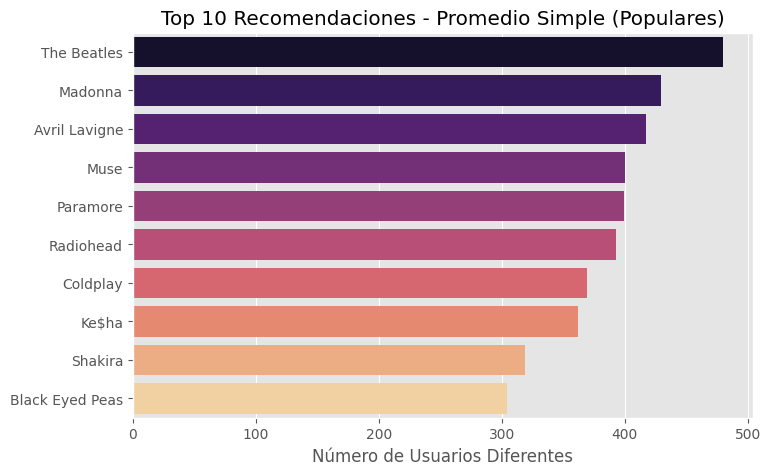

In [36]:
# Utilice este espacio para escribir el código.

#### 1. Recomendaciones para el usuario número ocho

### a. Filtramos por el usuario ocho, los artistas que ha escuchado (sin duplicados)
u8_artists_known = df_music.loc[df_music['userID'] == 8]['artistID'].unique()

### b. Excluyendo los artistas que ya conoce el usuario número ocho
df_filter = df_music[~df_music['artistID'].isin(u8_artists_known)]

### c. Calculamos el promedio simple 
mean_8 = df_filter.groupby(['artistID', 'artistName']).size().reset_index(name = 'num_usuarios')

### d. Top 10 de las recomendaciones para el usuario número ocho
top_10_recomend = mean_8.sort_values(by = 'num_usuarios', 
                                     ascending = False).head(10)

### e. Barplot con el top 10 de las recomendaciones para el usuario ocho
plt.figure(figsize = (8, 5))
sns.barplot(x = 'num_usuarios', 
            y = 'artistName', 
            data = top_10_recomend, 
            hue = 'artistName', 
            palette = 'magma', 
            legend = False)
plt.title('Top 10 Recomendaciones - Promedio Simple (Populares)')
plt.xlabel('Número de Usuarios Diferentes')
plt.ylabel('')
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**Artistas conocidos:** para poder obtener los artistas que son conocidos por el usuario número ocho, realizamos un filtro (mediante *loc*) para los *userID* iguales a 8, y agrupamos por los (únicos) nombres de los artistas disponibles en el DataFrame.

**Filtrando los artistas desconocidos:** el siguiente paso consiste en filtrar los artistas que ya son conocidos por el usuario número ocho, esto se hace mediante un filtro con la función *isin()* y con el caracter virgulilla (~) filtramos los artistas conocidos para quedarnos únicamente con los que no has sido escuchados por el usuario ocho.

**Promedio simple:** el cálculo de esta métrica agrupamos el DataFrame, previamente filtrado, por las columnas *artistID* y *artistName* y calculamos el tamaño de cada una de sus respectivas categorías y reseteamos el índice.

**DataFrame del Top 10:** creamos un nuevo objeto, *top_10_recomend *, que solo contiene el top 10 de las recomendaciones de artistas para el usuario ocho.

**Barplot de las recomendaciones:** el sistema de recomendación por promedio simple muestra en primer lugar a **The Beatles**, con 500 usuarios diferentes, y podemos ver que las recomendaciones se centran en artistas muy populares de la industria (no se tienen en cuenta los nichos) y también se está ignorando la personalización lo los gustos del susrio número ocho, ya que solo se tiene en cuenta lo más popular entre todos los consumidores de música.

#### 3.2.  Filtrado colaborativo sencillo: promedios ponderados.

Usando el promedio ponderado basado en el número de usuarios que escucha un artista  y ponderando  por el número de veces que estos usuarios reproducen al artista (`nro_reproducciones`) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.


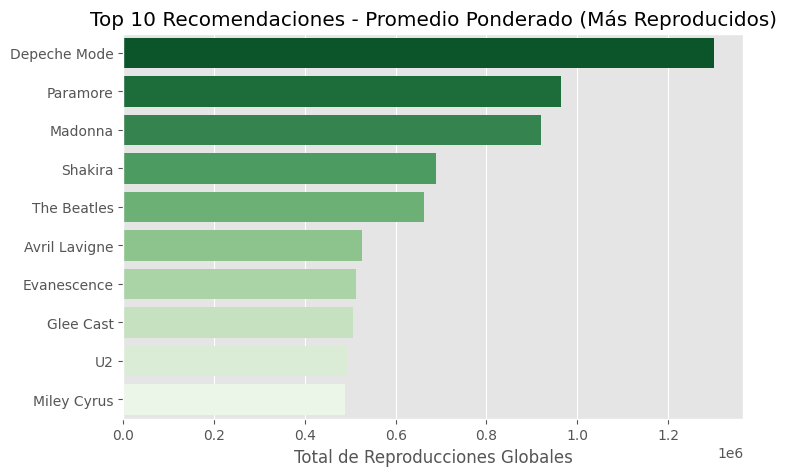

In [37]:
# Utilice este espacio para escribir el código.

#### 1. Sistema de recomendaciones por promedio ponderado

### a. Agrupamos el DataFrame filtrado por la suma de nro_reproducciones
mean_weight_8 = df_filter.groupby(['artistID', 'artistName'])['nro_reproducciones'].sum().reset_index()

### b. Construímos el Top 10 de los artistas ponderados
top10_weight = mean_weight_8.sort_values(by = 'nro_reproducciones', ascending = False).head(10)

### c. Barplot ponderado
plt.figure(figsize = (8, 5))
sns.barplot(x = 'nro_reproducciones', 
            y = 'artistName', 
            hue = 'artistName',
            data = top10_weight, 
            palette = 'Greens_r', 
            legend = False)
plt.title('Top 10 Recomendaciones - Promedio Ponderado (Más Reproducidos)')
plt.xlabel('Total de Reproducciones Globales')
plt.ylabel('')
plt.show()

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**Descripción del código:** agrupamos el DataFrame, filtrado, por las columnas *artistID* y *artistName* con la suma de columna de los weights. Posteriormente, creamos un DataFrame con el top 10 de los valores previamente calculados.

**Interpretación del Barplot:** en el caso de los valores ponderados, se toma en cuenta la lealtad (los nichos) sobre la popularidad masiva del promedio simple. Los resultados para el usuario número ocho son Depeche Mode como recomendación principal, seguido por Paramore y Madonna, acá empezamos a ver gustos musicales más específicos, respecto a los gustos masivos de todos los usuarios del DataFrame original.

#### 3.3.  Filtrado colaborativo sencillo: similitud de coseno.

Usando el promedio ponderado de reproducciones genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario. Para generar los pesos utilice la distancia de coseno. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.

In [38]:
# Utilice este espacio para escribir el código.

#### 1. Usando la distancia del Coseno

### a. Creamos una matriz Usuario Artista
artist_user = df_music.pivot(index = 'userID', 
                             columns = 'artistID', 
                             values = 'nro_reproducciones').fillna(0)

### b. Similitudes del usuario número ocho con el resto de usuarios

## Tomamos los índices del usuario número ocho
user8_idx = artist_user.index.get_loc(8)

## Artistas similares
simil = cosine_similarity(artist_user.iloc[user8_idx].values.reshape(1, -1), 
                          artist_user)[0]

### c. Construimos un DataFrame con los artistas similares

## El DataFrame df_similares contiene las columnas de artistas y similitudes
df_similares = pd.DataFrame({'userID': artist_user.index, 
                             'similitud': simil})

## Filtramos a los usuarios diferentes del usuario número ocho
df_similares = df_similares[df_similares['userID'] != 8]

### d. Cruzamos los datos originales y excluímos los artistas que ya son conocidos por el usuario ocho
df_sim_music = pd.merge(df_music[~df_music['artistID'].isin(u8_artists_known)], 
                        df_similares, 
                        on = 'userID')

### e. Multiplicamos las reproducciones por las similitudes para obtener los pesos de las similitudes
df_sim_music['peso_similitud'] = df_sim_music['nro_reproducciones'] * df_sim_music['similitud']

### f. Agrupamos por artista y construimos el top 10

## Agrupamos los artistas por la suma del peso de las reproducciones y reseteamos los índices
top10_coseno = df_sim_music.groupby('artistName')['peso_similitud'].sum().reset_index()

## Ordenamos de mayor a menor los pesos
top10_coseno = top10_coseno.sort_values(by='peso_similitud', 
                                        ascending=False).head(10)

### g. Tabla del Top 10 de los pesos de las similitudes
display(top10_coseno)

,artistName,peso_similitud
9102,Madonna,107592.450263
8246,Kylie Minogue,65695.295774
12778,Shakira,58792.638833
9783,Miley Cyrus,58350.409055
7915,Ke$ha,55946.028567
1408,Avril Lavigne,49811.083135
11033,Paramore,41671.427009
5860,Glee Cast,32286.278024
1943,Black Eyed Peas,25303.887098
1265,Ashley Tisdale,24169.791400


(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

**Descripción del código:** iniciamos con el pivote de *df_music*, rellenamos los campos vacíos con valores iguales a cero, y tomamos los índices que sean iguales a ocho. Para calcular la distancia del coseno, usamos la función *cosine_similarity()* y guardamos los resultados en el objeto *simil*, pasamos a construir el DataFrame de nombre *df_similares* con los resultados de las distancias y filtramos retirando las filas que corresponden al usuario número ocho. El siguiente paso consiste en un nuevo DataFrame, *df_sim_music*, que es un merge entre *df_music* con *df_similares* a través del ID de los usuarios, realizamos la multiplicación de las similitudes con los pesos, finalmente calculamos el Top 10 de los nuevos pesos calculados con la distancia del coseno que correponde al objeto *top10_coseno*.

**Interpretación de la tabla de salida:** a partir de la distancia del coseno entre el vector del usuario ocho con el resto de usuarios para encontrar los artistas similares en gustos, posteriormente, las reproducciones de los demás usuarios se ponderan con la similitud del usuario ocho. La tabla resultante del Top 10 (*top10_coseno*) nos muestra que han desaparecido los artistas con elevada popularidad, como los vistos en el promedio simple, y se reemplaza por el género Pop que es más de nicho al que parece que pertenece el usuario ocho. 

#### 3.4.  Filtrado colaborativo usando SVD


Usando la descomposición en valores singulares (SVD) genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores.


In [ ]:
# Utilice este espacio para escribir el código.

#### 1. Implementando el filtro con SVD

### a. Centrado de datos (valores absolutos a valores relativos)

## Extraemos los valores numéricos de la matriz y creamos un array de numpy
R = artist_user.values

## Sacamos el promedio simple de cada fila de los valores
user_ratings_mean = np.mean(R, axis = 1)

## Restamos los promedios a cada valor de la matriz original
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

##

### b. 

### c.

### d.

### e.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.5.  Filtrado colaborativo usando Análisis de Canasta de Compra

Usando  el algoritmo `Apriori` genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores. Esto puede tomar mucho tiempo, sea cuidadoso al elegir los hiper-parámetors del modelo, utilice los resultados de las estadísticas descriptivas para elegir sus hier-parámetros, y genere solo reglas con 2 elementos. (Puede también aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


In [40]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

### 4. Recomendaciones generales

De acuerdo con los resultados encontrados, en su opinión ¿qué procedimiento generó las mejores recomendaciones para este usuario? ¿Cómo implementaría una evaluación objetiva de estas recomendaciones? Justifique su respuesta.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).